In [1]:
import itertools

import altair as alt
import geopandas as gpd
import numpy as np
import pandas as pd
import shapely
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from scipy.optimize import minimize
from scipy.stats import norm

Adapted from Penner (Can J Phys 2002): The physics of putting

## Level green (Stimpmeter)

A golf ball with mass $m$ and moment of inertia $I$ is rolling along the $y$-direction on a level green ($x=z=0$).
The friction force (of the deformed green on the ball) is resolved in a component $n$ perpendicular to the surface and a component $f$ parallel to the surface.
The golf ball has radius $R$ and the friction force acts a distance $\rho$ ahead of and $R_t=\sqrt{R^2-\rho^2} \approx R$ below the center of mass.

The equations of motion are:

$$
ma_y = -f \\
I\alpha_x = n\rho - fR_t
$$

To simplify the analysis considerably, the ball is assumed to be rolling throughout, i.e.

$$
a_y = -\alpha_x R
$$

No acceleration in the $z$-direction means

$$
n = mg
$$

and solving all the above gives

$$
a_y = \frac{-g}{1 + \frac{I}{m R^2}} \frac{\rho}{R}
$$

which Penner gives as 

$$
a_y = -\frac{5}{7} \rho_g g
$$

where $\rho_g = \frac{\rho}{R}$ and using $I = I_b m R^2 = \frac{2}{5}mR^2$ for a uniform sphere.

A golf ball leaves a Stimpmeter at a speed of $v_0 = 6 $ (in ft/s) and travels a distance $y$ (also in feet).
It will come to a complete stop after a time 

$$
t = -\frac{v_0}{a_y}
$$

and the distance travelled obeys

$$
y = v_o t + \frac{1}{2} a_y t^2
$$

such that 

$$
y = - \frac{v_0^2}{2 a_y}
$$

Using $a_y$ from above gives an expression for $\rho_g$ in terms of the Stimpmeter reading $y$:

$$
\rho_g = \frac{v_0^2}{2 y} \frac{1 + \frac{I}{mR^2}}{g} \\
\rho_g = \frac{(6 ft/s)^2}{2 y} \frac{1 + I_b}{32.1 ft/s^2} \\
\rho_g = \frac{126.0 ft}{5 \times 32.1 y} \\
\rho_g = \frac{0.785 ft}{y}
$$

In [2]:
def softness(stimp_reading, *, ball_moi = 0.4):
    init_ball_speed = 6  # in feet per second
    gravity = 32.1  # feet / second^2
    return (init_ball_speed**2) * (1.0 + ball_moi) / (2 * gravity * stimp_reading)

In [3]:
softness(np.linspace(4.0, 13.0, 10))

array([0.19626168, 0.15700935, 0.13084112, 0.11214953, 0.09813084,
       0.08722741, 0.07850467, 0.07136788, 0.06542056, 0.06038821])

In [4]:
np.sqrt(1.0 - softness(np.linspace(4.0, 13.0, 10))**2)

array([0.98055156, 0.98759712, 0.99140335, 0.99369134, 0.99517352,
       0.99618843, 0.99691375, 0.99745006, 0.99785778, 0.99817497])

Consider now a sloped green with angles with respect to the horizontal of $\theta$ along the $x$-axis, and of $\psi$ along the $y$-axis.
The gravitational force (weight) is given as
$$
\vec{W} = -mg (\sin \theta, \cos \theta \sin \psi, \cos \theta \cos \psi).
$$
by Penner, but I do not believe this because it is not symmetrical if $x$ and $y$ (and $\theta$ and $\psi$) are interchanged.

In the case where $\psi = 0$, $\bm{\hat{\jmath}} = \bm{\hat{y}}$ and the weight vector should be given by
$$
\vec{W} = -mg(\sin \theta, 0, \cos \theta)
$$
and where $\theta = 0$, it is
$$
\vec{W} = -mg
$$


The ball is assumed to be moving with velocity $\vec{v}$ which makes an angle $\beta$ to the positive $y$-axis, and the friction force is given by $\vec{f}$ which makes an angle $\phi$ with the negative $y$-axis. (See Penner Fig. 2)
The friction force is
$$
\vec{f} = (-f \sin \phi, -f \cos \phi, n).
$$
(Should also be the other way around?)

In [5]:
GRAVITY = 9.8  # m/s^2
MOI_SOLID_SPHERE = 0.4
BALL_RADIUS = 0.02135  # m
HOLE_RADIUS = 0.054  # m

In [6]:
softness(12)

0.06542056074766354

In [7]:
class Green:
    def __init__(
        self,
        stimp,
        *,
        gdf=None,
        hole_location=None,
        hole_radius=HOLE_RADIUS,
        holing_vmax=1.63
    ):
        self.stimp = stimp
        self.softness = softness(stimp, ball_moi=MOI_SOLID_SPHERE)
        self.gdf = gdf
        self.hole_location = (0.0, 0.0) if hole_location is None else hole_location
        self.hole_radius = hole_radius
        self.hole_radius_squared = hole_radius * hole_radius
        self.holing_vmax = holing_vmax

    def normal(self, x, y):
        return [0.0, 0.1, np.sqrt(0.99)]

    def impact_function(self, u):
        x, y, vx, vy = u
        x0, y0 = self.hole_location
        squared_distance_to_hole = (x - x0) * (x - x0) + (y - y0) * (y - y0)
        impact = squared_distance_to_hole / self.hole_radius_squared
        v = np.sqrt(vx * vx + vy * vy)
        return v - self.holing_vmax * (1.0 - impact)


In [8]:
def simple_roll(t, u, green):
    x, y, vx, vy = u
    dx = vx
    dy = vy

    g = GRAVITY
    I_b = MOI_SOLID_SPHERE
    rho_g = green.softness

    nx, ny, nz = green.normal(x, y)
    grade = np.sqrt(1.0 - nz * nz)
    v = np.sqrt(vx * vx + vy * vy)

    dvx = (g / I_b) * (grade * nx - rho_g * vx / v)
    dvy = (g / I_b) * (grade * ny - rho_g * vy / v)
    return [dx, dy, dvx, dvy]


In [9]:
class MinBallSpeed:
    def __init__(self, min_speed, *, terminal=True, direction=0):
        self.terminal = terminal
        self.direction = direction
        self.min_speed = min_speed

    def __call__(self, t, u, green):
        x, y, vx, vy = u
        v2 = vx * vx + vy * vy
        return v2 - self.min_speed * self.min_speed


In [10]:
class HoleCapture:
    def __init__(
        self, *, terminal=True, direction=0, vmax=1.63, hole_radius=HOLE_RADIUS
    ):
        self.terminal = terminal
        self.direction = direction
        self.vmax = vmax
        self.hole_radius = hole_radius
        self.hole_radius_squared = hole_radius * hole_radius

    def __call__(self, t, u, green):
        return green.impact_function(u)


In [11]:
tspan = [0, 10.0]
t_eval = np.linspace(*tspan, 10_001)
x0, y0 = (0.0, 3.0)
vx0, vy0 = (0.0, -3.0)
u0 = np.array([x0, y0, vx0, vy0])

In [12]:
sol = solve_ivp(
    simple_roll,
    tspan,
    u0,
    method="LSODA",
    events=[MinBallSpeed(1e-6), HoleCapture()],
    args=(Green(12.0),),
)

In [13]:
sol

  message: A termination event occurred.
  success: True
   status: 1
        t: [ 0.000e+00  3.148e-02 ...  1.624e+00  1.624e+00]
        y: [[ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
            [ 3.000e+00  2.907e+00 ...  5.665e-01  5.665e-01]
            [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
            [-3.000e+00 -2.942e+00 ... -1.352e-06 -1.000e-06]]
      sol: None
 t_events: [array([ 1.624e+00]), array([], dtype=float64)]
 y_events: [array([[ 0.000e+00,  5.665e-01,  0.000e+00, -1.000e-06]]), array([], dtype=float64)]
     nfev: 59
     njev: 0
      nlu: 0

In [14]:
len(sol.t)

15

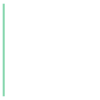

In [15]:
shapely.LineString(sol.y[0:2].T)

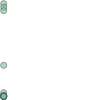

In [16]:
shapely.MultiPoint(sol.y[0:2].T)

In [17]:
sol.y[0:2].T

array([[0.        , 3.        ],
       [0.        , 2.90740205],
       [0.        , 2.81663481],
       [0.        , 1.38205264],
       [0.        , 0.66020962],
       [0.        , 0.59111435],
       [0.        , 0.56656529],
       [0.        , 0.5665374 ],
       [0.        , 0.56653305],
       [0.        , 0.56653133],
       [0.        , 0.56653079],
       [0.        , 0.56653076],
       [0.        , 0.56653076],
       [0.        , 0.56653076],
       [0.        , 0.56653076]])

In [18]:
sol.y.T[-1, 0:2]

array([0.        , 0.56653076])

In [19]:
hc = HoleCapture()
hc(0, sol.y.T[-1], Green(6.0))

177.78017691692898

In [20]:
4.4 * np.cos(3.2), 4.4 * np.sin(3.2)

(-4.392497013496914, -0.2568462310813524)

In [21]:
np.linspace(*tspan, 1001)

array([ 0.  ,  0.01,  0.02, ...,  9.98,  9.99, 10.  ])

In [22]:
tspan = [0, 10.0]
t_eval = np.linspace(*tspan, 10_001)
x0, y0 = (3.0, -0.2)

v_init = 3.2
vs = v_init * norm(1, 0.03).ppf(np.linspace(0.025, 0.975, 11))

theta_init = np.pi
thetas = norm(theta_init, np.deg2rad(1.0)).ppf(np.linspace(0.025, 0.975, 11))

end_points = list()
sols = list()
for v, theta in itertools.product(vs, thetas):
    vx0, vy0 = v * np.cos(theta), v * np.sin(theta)
    u0 = np.array([x0, y0, vx0, vy0])
    sol = solve_ivp(
        simple_roll,
        tspan,
        u0,
        method="Radau",
        t_eval=t_eval,
        events=[MinBallSpeed(1e-6), HoleCapture()],
        args=(Green(12.0),),
    )
    end_point = np.hstack(([v, theta], sol.y.T[-1]))
    end_points.append(end_point)
    sols.append(sol)

In [23]:
df = pd.DataFrame(end_points, columns=["v_init", "theta", "x", "y", "vx_end", "vy_end"])
df["v_end"] = np.sqrt(df["vx_end"]**2 + df["vy_end"]**2)

In [24]:
end_point_plot = (
    alt.Chart(df)
    .mark_point()
    .encode(
        longitude="x",
        latitude="y",
        color="v_end",
        tooltip=["v_init", "theta", "x", "y", "v_end"],
    )
    # .project(
    #     type="identity",
    #     reflectY=True,
    # )
    .properties(width=400, height=400)
)


In [25]:
hole_point = gpd.GeoDataFrame(
    geometry=[shapely.buffer(shapely.Point(0.0, 0.0), HOLE_RADIUS)],
)
hole_point
hole_plot = (
    alt.Chart(hole_point)
    .mark_geoshape(color="black")
    # .project(
    #     type="identity",
    #     reflectY=True,
    # )
)


In [26]:
(hole_plot + end_point_plot)

alt.LayerChart(...)

In [27]:
norm.ppf(np.linspace(0.025, 0.975, 11))

array([-1.95996398, -1.17498679, -0.78919165, -0.49585035, -0.24042603,
        0.        ,  0.24042603,  0.49585035,  0.78919165,  1.17498679,
        1.95996398])

In [28]:
df = pd.DataFrame(np.vstack(([sol.t], sol.y)).T, columns=["t", "x", "y", "vx", "vy"])
df["v"] = np.sqrt(df["vx"]**2 + df["vy"]**2)
df

,t,x,y,vx,vy,v
0,0.000,3.000000,-0.200000,-3.386174,-0.115879,3.388157
1,0.001,2.996615,-0.200116,-3.384572,-0.115579,3.386545
2,0.002,2.993231,-0.200231,-3.382971,-0.115279,3.384934
3,0.003,2.989849,-0.200346,-3.381369,-0.114980,3.383323
4,0.004,2.986468,-0.200461,-3.379767,-0.114681,3.381712
...,...,...,...,...,...,...
2149,2.149,-0.590617,-0.044844,-0.003753,0.004442,0.005815
2150,2.150,-0.590620,-0.044840,-0.002735,0.003449,0.004402
2151,2.151,-0.590623,-0.044837,-0.001764,0.002419,0.002994
2152,2.152,-0.590624,-0.044835,-0.000857,0.001343,0.001593


In [29]:
hole_plot + alt.Chart(df).mark_point(clip=True).encode(
    longitude="x",
    latitude="y",
    color="v",
)


alt.LayerChart(...)

In [30]:
tspan = [0, 10.0]
t_eval = np.linspace(*tspan, 10_001)
x0, y0 = (0.0, 3.0)
vx0, vy0 = (0.0, -3.0)
u0 = np.array([x0, y0, vx0, vy0])

In [31]:
sol = solve_ivp(
    simple_roll,
    tspan,
    u0,
    method="LSODA",
    dense_output=True,
    events=[MinBallSpeed(1e-6), HoleCapture()],
    args=(Green(12.0),),
)

In [32]:
sol

  message: A termination event occurred.
  success: True
   status: 1
        t: [ 0.000e+00  3.148e-02 ...  1.624e+00  1.624e+00]
        y: [[ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
            [ 3.000e+00  2.907e+00 ...  5.665e-01  5.665e-01]
            [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
            [-3.000e+00 -2.942e+00 ... -1.352e-06 -1.000e-06]]
      sol: <scipy.integrate._ivp.common.OdeSolution object at 0x0000020025CBAE60>
 t_events: [array([ 1.624e+00]), array([], dtype=float64)]
 y_events: [array([[ 0.000e+00,  5.665e-01,  0.000e+00, -1.000e-06]]), array([], dtype=float64)]
     nfev: 59
     njev: 0
      nlu: 0

In [33]:
df = pd.DataFrame(np.vstack(([sol.t], sol.y)).T, columns=["t", "x", "y", "vx", "vy"])
df["v"] = np.sqrt(df["vx"]**2 + df["vy"]**2)
df

,t,x,y,vx,vy,v
0,0.000000,0.0,3.000000,0.0,-3.000000e+00,3.000000e+00
1,0.031476,0.0,2.907402,0.0,-2.941838e+00,2.941838e+00
2,0.062952,0.0,2.816635,0.0,-2.883676e+00,2.883676e+00
3,0.684018,0.0,1.382053,0.0,-1.736069e+00,1.736069e+00
4,1.305083,0.0,0.660210,0.0,-5.884620e-01,5.884620e-01
5,1.460350,0.0,0.591114,0.0,-3.015603e-01,3.015603e-01
6,1.615616,0.0,0.566565,0.0,-1.465848e-02,1.465848e-02
7,1.620383,0.0,0.566537,0.0,-5.851087e-03,5.851087e-03
8,1.621574,0.0,0.566533,0.0,-3.649238e-03,3.649238e-03
9,1.622766,0.0,0.566531,0.0,-1.447390e-03,1.447390e-03


In [34]:
hc = HoleCapture()
hc(sol.t, sol.y.T[-1], Green(12.0))

177.78017691692898

In [35]:
df["capture"] = [hc(sol.t[i], sol.y.T[i], Green(12.0)) for i, _ in enumerate(sol.t)]
df["d2"] = df["x"]**2 + df["y"]**2
df["distance"] = np.sqrt(df["d2"])

In [36]:
hole_plot + alt.Chart(df[df["d2"] < 10.0]).mark_point(clip=True).encode(
    longitude="x",
    latitude="y",
    color=alt.Color("capture", scale=alt.Scale(type="symlog")),
    tooltip=["t", "x", "y", "v", "capture", "distance"]
)

alt.LayerChart(...)

In [37]:
i_nearest, t_nearest = min(
    enumerate(sol.t), key=lambda x: hc(x[1], sol.y.T[x[0]], Green(12.0))
)
i_nearest, t_nearest

(14, 1.6235485066889215)

In [38]:
t_min, t_max = sol.t[[i_nearest - 1, i_nearest]]

In [39]:
t_eval = np.arange(t_min, t_max+0.01, 0.01)
u_eval = sol.sol(t_eval).T

In [40]:
captures = np.array([hc(t, u, Green(12.0)) for t, u in zip(t_eval, u_eval)])
captures

array([177.78017727, 177.85716546])

In [41]:
impact_parameter = min(captures)
impact_parameter

177.78017726848262

In [42]:
holed = impact_parameter < 0
holed

False

In [43]:
np.amin([Green(12.0).impact_function(u) for u in sol.y.T])

177.78017691692898

In [44]:
def holing_objective(sol, green):
    i_nearest = np.argmin([green.impact_function(u) for u in sol.y.T])
    try:
        t_min = sol.t[i_nearest - 1]
    except IndexError:
        t_min = sol.t[0]
    try:
        t_max = sol.t[i_nearest + 1]
    except IndexError:
        t_max = sol.t[-1]
    t_eval = np.arange(t_min, t_max + 0.01, 0.01)
    u_eval = sol.sol(t_eval).T
    impact = np.amin([green.impact_function(u) for u in u_eval])
    return impact


In [45]:
def simulate_rolls(vs, thetas, green, init, *, tspan=(0.0, 10.0), method="LSODA", **kwargs):
    x0, y0 = init
    end_points = list()
    sols = list()
    impacts = list()
    for v, theta in itertools.product(vs, thetas):
        vx0, vy0 = v * np.cos(theta), v * np.sin(theta)
        u0 = np.array([x0, y0, vx0, vy0])
        sol = solve_ivp(
            simple_roll,
            tspan,
            u0,
            method=method,
            dense_output=True,
            events=[MinBallSpeed(1e-6)],
            args=(green,),
            **kwargs,
        )
        end_point = np.hstack(([v, theta], sol.y.T[-1]))
        impact = holing_objective(sol, green)
        end_points.append(end_point)
        sols.append(sol)
        impacts.append(impact)

    return end_points, sols, impacts

In [46]:
broadie_putts_gained = pd.DataFrame(
    {
        "distance_ft": [0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 30, 40, 50, 60, 90],
        "avg_putts": [
            1.0,
            1.01,
            1.05,
            1.14,
            1.24,
            1.34,
            1.43,
            1.5,
            1.56,
            1.61,
            1.78,
            1.87,
            1.98,
            2.06,
            2.14,
            2.21,
            2.36,
        ],
    }
)
ONE_FOOT = 0.305
approx_putts = interp1d(
    broadie_putts_gained["distance_ft"] * ONE_FOOT,
    broadie_putts_gained["avg_putts"],
)


In [47]:
broadie_putts_gained

,distance_ft,avg_putts
0,0,1.00
1,2,1.01
2,3,1.05
3,4,1.14
4,5,1.24
5,6,1.34
6,7,1.43
7,8,1.50
8,9,1.56
9,10,1.61


In [48]:
def aim_objective_inner(x, green, init_position, *, v_cv=0.06, theta_sd=np.deg2rad(1.0)):
    v, theta = x

    vs = v * np.geomspace(1.0 - 2 * v_cv, 1.0 + 2 * v_cv, 9)
    thetas = theta + np.linspace(-2 * theta_sd, 2 * theta_sd, 9)
    # vs = v * norm(1, v_cv).ppf(np.linspace(0.025, 0.975, 11))
    # thetas = norm(theta, np.deg2rad(theta_sd)).ppf(np.linspace(0.025, 0.975, 11))
    return simulate_rolls(vs, thetas, green, init_position)


In [49]:
weights = [
    norm.pdf(x) * norm.pdf(y)
    for x, y in itertools.product(np.linspace(-2.0, 2.0, 9), np.linspace(-2.0, 2.0, 9))
]
weights /= sum(weights)


def aim_objective(*args, **kwargs):
    try:
        end_points, _, impacts = aim_objective_inner(*args, **kwargs)
    except:
        return np.Inf
    scores = [
        approx_putts(np.sqrt(u[2] ** 2 + u[3] ** 2)) if impact >= 0 else 0
        for u, impact in zip(end_points, impacts)
    ]

    return sum(score * weight for score, weight in zip(scores, weights))


In [50]:
optim_result = minimize(
    aim_objective,
    (3.0, np.pi),
    args=(Green(12.0), (3.05, 0.0)),
    method="Nelder-Mead",
    bounds=[(0.0, 10.0), (0, 2*np.pi)],
    options={"maxiter": 50, "disp": True},
)
optim_result

Optimization terminated successfully.
         Current function value: 0.651110
         Iterations: 46
         Function evaluations: 97


       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.6511097822685162
             x: [ 3.235e+00  3.205e+00]
           nit: 46
          nfev: 97
 final_simplex: (array([[ 3.235e+00,  3.205e+00],
                       [ 3.235e+00,  3.205e+00],
                       [ 3.235e+00,  3.205e+00]]), array([ 6.511e-01,  6.511e-01,  6.511e-01]))

In [51]:
end_points, _, impacts = aim_objective_inner(optim_result.x, Green(12.0), (3.05, 0.0))

In [52]:
df = pd.DataFrame(end_points, columns=["v_init", "theta", "x", "y", "vx_end", "vy_end"])
df["impact"] = impacts
df["holed"] = df["impact"] < 0.0
df["weight"] = weights

In [53]:
sum(df["weight"][df["holed"]])

0.3561658453754755

In [54]:
hole_plot + (
    alt.Chart(df)
    .mark_point(filled=True)
    .encode(
        longitude="x",
        latitude="y",
        color="holed",
        opacity="weight",
        shape="holed",
        tooltip=["v_init", "theta", "x", "y", "impact", "weight"],
    )
    # .project(
    #     type="identity",
    #     reflectY=True,
    # )
    .properties(width=400, height=400)
)

alt.LayerChart(...)

In [55]:
optim_result = minimize(
    aim_objective,
    (2.0, np.pi),
    args=(Green(12.0), (0.915, 0.0)),
    method="Nelder-Mead",
    bounds=[(0.0, 10.0), (0, 2*np.pi)],
    options={"maxiter" :50, "disp": True},
)
optim_result

Optimization terminated successfully.
         Current function value: 0.020206
         Iterations: 38
         Function evaluations: 75


       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.020205595455760554
             x: [ 1.907e+00  3.189e+00]
           nit: 38
          nfev: 75
 final_simplex: (array([[ 1.907e+00,  3.189e+00],
                       [ 1.907e+00,  3.188e+00],
                       [ 1.907e+00,  3.188e+00]]), array([ 2.021e-02,  2.021e-02,  2.021e-02]))

In [56]:
end_points, _, impacts = aim_objective_inner(optim_result.x, Green(12.0), (0.915, 0.0))

In [57]:
df = pd.DataFrame(end_points, columns=["v_init", "theta", "x", "y", "vx_end", "vy_end"])
df["impact"] = impacts
df["holed"] = df["impact"] < 0.0
df["weight"] = weights

In [58]:
sum(df["weight"][df["holed"]])

0.9799110424663932

In [59]:
hole_plot + (
    alt.Chart(df)
    .mark_point(filled=True)
    .encode(
        longitude="x",
        latitude="y",
        color="holed",
        opacity="weight",
        shape="holed",
        tooltip=["v_init", "theta", "x", "y", "impact", "weight"],
    )
    # .project(
    #     type="identity",
    #     reflectY=True,
    # )
    .properties(width=400, height=400)
)

alt.LayerChart(...)

In [60]:
optim_result = minimize(
    aim_objective,
    (2.0, np.pi),
    args=(Green(12.0), (0.61, 0.0)),
    method="Nelder-Mead",
    bounds=[(0.0, 10.0), (0, 2*np.pi)],
    options={"maxiter" :50, "disp": True},
)
optim_result

Optimization terminated successfully.
         Current function value: 0.000000
         Iterations: 23
         Function evaluations: 66


       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.0
             x: [ 1.605e+00  3.166e+00]
           nit: 23
          nfev: 66
 final_simplex: (array([[ 1.605e+00,  3.166e+00],
                       [ 1.605e+00,  3.166e+00],
                       [ 1.605e+00,  3.166e+00]]), array([ 0.000e+00,  0.000e+00,  0.000e+00]))

In [61]:
end_points, _, impacts = aim_objective_inner(optim_result.x, Green(12.0), (0.61, 0.0))

In [62]:
df = pd.DataFrame(end_points, columns=["v_init", "theta", "x", "y", "vx_end", "vy_end"])
df["impact"] = impacts
df["holed"] = df["impact"] < 0.0
df["weight"] = weights

In [63]:
sum(df["weight"][df["holed"]])

1.0000000000000002

In [64]:
hole_plot + (
    alt.Chart(df)
    .mark_point(filled=True)
    .encode(
        longitude="x",
        latitude="y",
        color="holed",
        opacity="weight",
        shape="holed",
        tooltip=["v_init", "theta", "x", "y", "impact", "weight"],
    )
    # .project(
    #     type="identity",
    #     reflectY=True,
    # )
    .properties(width=400, height=400)
)

alt.LayerChart(...)

In [65]:
optim_result = minimize(
    aim_objective,
    (4.0, 1.5*np.pi),
    args=(Green(12.0), (0.0, 3.05)),
    method="Nelder-Mead",
    bounds=[(0.0, 10.0), (0, 2*np.pi)],
    options={"maxiter": 50, "disp": True},
)
optim_result

Optimization terminated successfully.
         Current function value: 0.697071
         Iterations: 46
         Function evaluations: 88


       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.6970705867745088
             x: [ 3.570e+00  4.709e+00]
           nit: 46
          nfev: 88
 final_simplex: (array([[ 3.570e+00,  4.709e+00],
                       [ 3.570e+00,  4.709e+00],
                       [ 3.570e+00,  4.709e+00]]), array([ 6.971e-01,  6.971e-01,  6.971e-01]))

In [66]:
end_points, _, impacts = aim_objective_inner(optim_result.x, Green(12.0), (0.0, 3.05))

In [67]:
df = pd.DataFrame(end_points, columns=["v_init", "theta", "x", "y", "vx_end", "vy_end"])
df["impact"] = impacts
df["holed"] = df["impact"] < 0.0
df["weight"] = weights

In [68]:
sum(df["weight"][df["holed"]])

0.31932979416390234

In [69]:
hole_plot + (
    alt.Chart(df)
    .mark_point(filled=True)
    .encode(
        longitude="x",
        latitude="y",
        color="holed",
        opacity="weight",
        shape="holed",
        tooltip=["v_init", "theta", "x", "y", "impact", "weight"],
    )
    # .project(
    #     type="identity",
    #     reflectY=True,
    # )
    .properties(width=400, height=400)
)

alt.LayerChart(...)

In [70]:
optim_result = minimize(
    aim_objective,
    (4.0, 0.5*np.pi),
    args=(Green(12.0), (0.0, -3.05)),
    method="Nelder-Mead",
    bounds=[(0.0, 10.0), (0, 2*np.pi)],
    options={"maxiter": 50, "disp": True},
)
optim_result

C:\Users\istvan\AppData\Local\Temp\ipykernel_25908\4248291265.py:1: RuntimeWarning: Maximum number of iterations has been exceeded.
  optim_result = minimize(


       message: Maximum number of iterations has been exceeded.
       success: False
        status: 2
           fun: 0.5668239515910626
             x: [ 2.970e+00  1.568e+00]
           nit: 50
          nfev: 101
 final_simplex: (array([[ 2.970e+00,  1.568e+00],
                       [ 2.970e+00,  1.568e+00],
                       [ 2.971e+00,  1.568e+00]]), array([ 5.668e-01,  5.668e-01,  5.668e-01]))

In [71]:
end_points, _, impacts = aim_objective_inner(optim_result.x, Green(12.0), (0.0, -3.05))

In [72]:
df = pd.DataFrame(end_points, columns=["v_init", "theta", "x", "y", "vx_end", "vy_end"])
df["impact"] = impacts
df["holed"] = df["impact"] < 0.0
df["weight"] = weights

In [73]:
sum(df["weight"][df["holed"]])

0.4393340094738206

In [74]:
hole_plot + (
    alt.Chart(df)
    .mark_point(filled=True)
    .encode(
        longitude="x",
        latitude="y",
        color="holed",
        opacity="weight",
        shape="holed",
        tooltip=["v_init", "theta", "x", "y", "impact", "weight"],
    )
    # .project(
    #     type="identity",
    #     reflectY=True,
    # )
    .properties(width=400, height=400)
)

alt.LayerChart(...)

In [75]:
sum([
    norm.pdf(x) * norm.pdf(y)
    for x, y in itertools.product(
        np.linspace(-2.0, 2.0, 9), np.linspace(-2.0, 2.0, 9)
    )
])

3.8182391316245883

In [76]:
sum([
    norm.pdf(x) * norm.pdf(y)
    for x, y in itertools.product(
        np.linspace(-2.5, 2.5, 11), np.linspace(-2.5, 2.5, 11)
    )
])

3.956471502634635

In [77]:
sum([
    norm.pdf(x) * norm.pdf(y)
    for x, y in itertools.product(
        np.linspace(-3.0, 3.0, 13), np.linspace(-3.0, 3.0, 13)
    )
])


3.991811415652157

In [78]:
sum([
    norm.pdf(x) * norm.pdf(y)
    for x, y in itertools.product(
        np.linspace(-4.0, 4.0, 17), np.linspace(-4.0, 4.0, 17)
    )
])

3.9998593251533032